In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
# Load from local CSV files
df_train = pd.read_csv('data/raw/banking77-train.csv')
df_test = pd.read_csv('data/raw/banking77-test.csv')

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

In [ ]:
# Missing values check
print("=== Missing Values ===")
print(f"Train: {df_train.isnull().sum().sum()} missing values")
print(f"Test: {df_test.isnull().sum().sum()} missing values")

In [ ]:
# Unique intents verification
print("=== Unique Intents ===")
print(f"Unique intents in train: {df_train['label_text'].nunique()}")
print(f"Unique intents in test: {df_test['label_text'].nunique()}")
print("\nAll intents:", sorted(df_train['label_text'].unique()))

In [4]:
# Display basic information about the datasets
print(f"Training set size: {df_train.shape}")
print(f"Testing set size: {df_test.shape}")

# Display the first few rows of the training set
df_train.head()

Training set size: (9993, 3)
Testing set size: (3076, 3)


,text,label,label_text
0,I am still waiting on my card?,11,card_arrival
1,What can I do if my card still hasn't arrived ...,11,card_arrival
2,I have been waiting over a week. Is the card s...,11,card_arrival
3,Can I track my card while it is in the process...,11,card_arrival
4,"How do I know if I will get my card, or if it ...",11,card_arrival


In [5]:
# Extract the intent labels and their counts
label_summary = df_train['label_text'].value_counts().reset_index()
label_summary.columns = ['Label Name', 'Count']
label_summary

,Label Name,Count
0,card_payment_fee_charged,187
1,direct_debit_payment_not_recognised,182
2,balance_not_updated_after_cheque_or_cash_deposit,181
3,wrong_amount_of_cash_received,180
4,cash_withdrawal_charge,177
...,...,...
72,lost_or_stolen_card,82
73,card_swallowed,61
74,card_acceptance,59
75,virtual_card_not_working,41


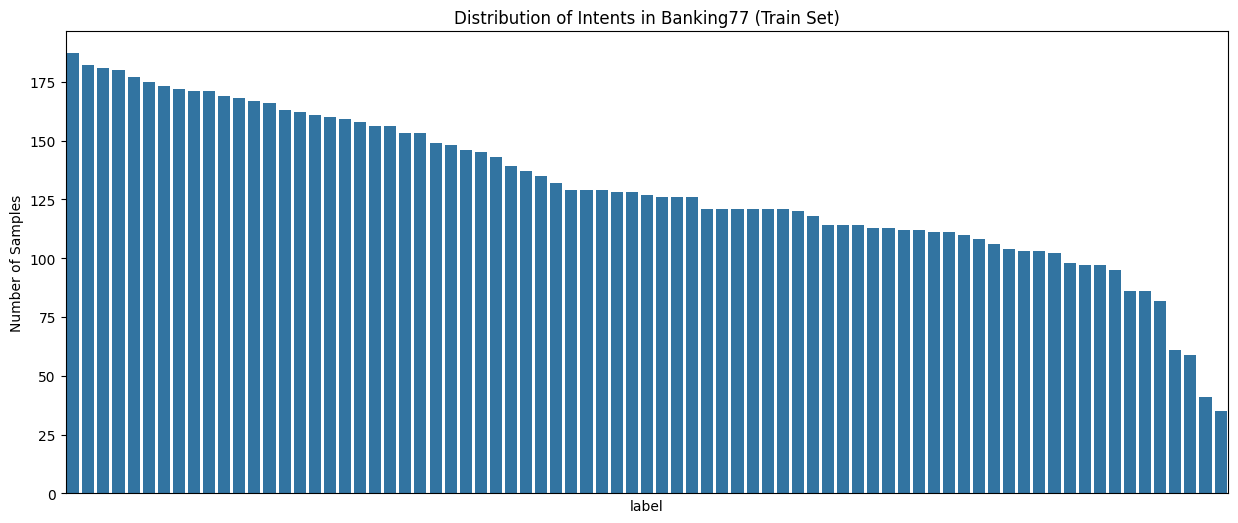

In [6]:
plt.figure(figsize=(15, 6))
sns.countplot(data=df_train, x='label', order=df_train['label'].value_counts().index)
plt.title('Distribution of Intents in Banking77 (Train Set)')
plt.xticks([]) # Hide x-axis labels for better readability
plt.ylabel('Number of Samples')
plt.show()

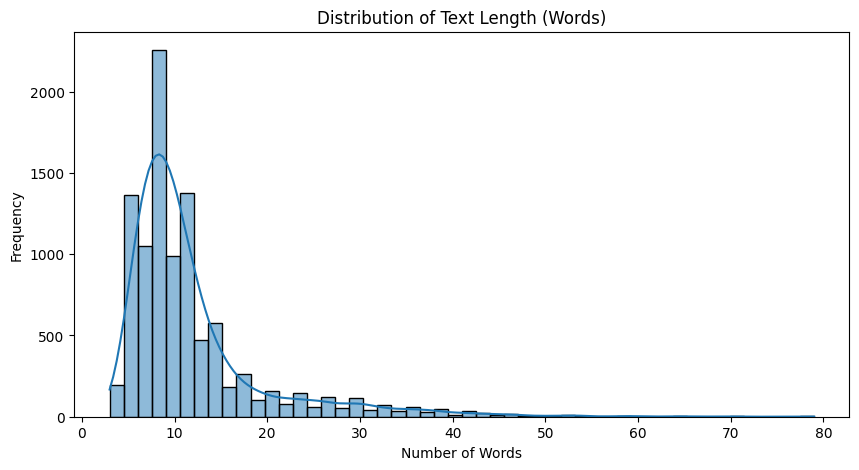

Maximum word count: 79
Average word count: 11.96


In [7]:
df_train['word_count'] = df_train['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(df_train['word_count'], bins=50, kde=True)
plt.title('Distribution of Text Length (Words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

print(f"Maximum word count: {df_train['word_count'].max()}")
print(f"Average word count: {df_train['word_count'].mean():.2f}")